# Entrenamiento Faster R-CNN

Segundo intento AAAA

**v2 — mejoras aplicadas:** fine-tuning parcial del backbone (layer3/layer4), pérdida ponderada por clase + Focal Loss para el desbalance, augmentation menos agresivo, LR diferencial + cosine annealing, y diagnóstico de AP por clase sin threshold de score.

In [1]:
!pip install roboflow albumentations torchmetrics tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


## 1. Imports

In [2]:
import time
import json
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import torch
import torch.nn.functional as F
import numpy as np
import torchvision
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm import tqdm
from PIL import Image
from roboflow import Roboflow
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
import torchvision.models.detection.roi_heads as _roi_heads_module


## 2. Configuración

In [3]:
CONFIG = {
    # Dataset Roboflow
    "roboflow_api_key": "Az5***Aj",
    "roboflow_workspace": "joses-workspace-nqi4z",
    "roboflow_project": "Carritos-Detector",
    "roboflow_version": 1,
    "dataset_dir": "./Carritos-Detector-1",

    # Split
    "train_ratio": 0.80,
    "val_ratio":   0.10,
    "test_ratio":  0.10,

    # Modelo
    "num_classes": 9 + 1,      # 9 clases + background
    "unfreeze_layers": ("layer3", "layer4"),   # capas del backbone que SI se entrenan (fine-tuning)

    # Entrenamiento
    "epochs": 30,
    "batch_size": 2,
    "lr_head": 1e-3,           # LR para RPN + ROI heads (capas nuevas / re-inicializadas)
    "lr_backbone": 1e-4,       # LR mas bajo para layer3/layer4 descongeladas (fine-tuning suave)
    "weight_decay": 5e-4,
    "num_workers": 2,
    "seed": 42,

    # Scheduler
    "scheduler": "cosine",     # antes: StepLR con decaimiento agresivo (apagaba el LR desde la epoca 20)
    "lr_min": 1e-6,

    # Manejo de desbalance de clases
    "use_class_weights": True,
    "use_focal_loss": True,
    "focal_gamma": 2.0,
    "class_weight_max": 8.0,   # clip para no sobre-corregir clases ultra raras (Motocarga, etc.)

    # Evaluacion
    "iou_thresholds": [0.50, 0.75],
    "score_threshold": 0.5,

    # Checkpoints
    "checkpoint_dir": "./checkpoints",
    "save_every": 5,
}


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Usando dispositivo: {DEVICE}")


[INFO] Usando dispositivo: cuda


In [5]:
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])


## 3. Dataset
El dataset fue hecho manualmente desde Roboflow. El grupo estuvo clasificando todas las imagenes y asignando cada objeto una clase respectiva.

Para poder usarlo, usamos la vía de cargarla desde la nube que ofrece el mismo Roboflow.

In [6]:
rf = Roboflow(api_key=CONFIG["roboflow_api_key"])
workspace = rf.workspace("joses-workspace-nqi4z")
print(workspace.projects())


loading Roboflow workspace...
['joses-workspace-nqi4z/carritos-detector']


In [7]:
project = rf.workspace("joses-workspace-nqi4z").project("carritos-detector")
print(project.versions())


loading Roboflow workspace...
loading Roboflow project...


In [8]:
dataset_dir = Path(CONFIG["dataset_dir"])
if dataset_dir.exists():
    print(f"[INFO] Dataset ya encontrado en: {dataset_dir}")
else:
    print("[INFO] Descargando dataset desde Roboflow...")
    rf = Roboflow(api_key=CONFIG["roboflow_api_key"])
    project = rf.workspace("joses-workspace-nqi4z").project("carritos-detector")
    dataset = project.version(1).download("coco")


[INFO] Descargando dataset desde Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Carritos-Detector-1 in coco:: 100%|██████████| 1014/1014 [00:00<00:00, 5568.21it/s]


## 4. Parseo de anotaciones COCO y splits

In [9]:
def load_coco_annotations(json_path: str):
    with open(json_path, "r") as f:
        coco = json.load(f)
    categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
    ann_by_image = defaultdict(list)
    for ann in coco["annotations"]:
        ann_by_image[ann["image_id"]].append(ann)
    images = [img for img in coco["images"] if ann_by_image[img["id"]]]
    return images, ann_by_image, categories


In [10]:
# Detectar splits de Roboflow (train/valid/test)
roboflow_splits = {
    "train": dataset_dir / "train",
    "val":   dataset_dir / "valid",
    "test":  dataset_dir / "test",
}
has_roboflow_splits = all(
    (p / "_annotations.coco.json").exists() for p in roboflow_splits.values()
)

if has_roboflow_splits:
    print("[INFO] Splits de Roboflow detectados (train/valid/test).")
    splits = {}
    categories = None
    for split_name, split_dir in roboflow_splits.items():
        images, ann_by_image, cats = load_coco_annotations(
            str(split_dir / "_annotations.coco.json")
        )
        splits[split_name] = {
            "images": images,
            "ann_by_image": ann_by_image,
            "img_dir": split_dir,
        }
        if categories is None:
            categories = cats
else:
    all_jsons = list(dataset_dir.rglob("_annotations.coco.json"))
    if not all_jsons:
        raise FileNotFoundError(f"No se encontró ningún _annotations.coco.json en {dataset_dir}")
    json_path = all_jsons[0]
    img_dir = json_path.parent
    print(f"[INFO] Split manual 80/10/10 desde: {json_path}")
    images, ann_by_image, categories = load_coco_annotations(str(json_path))
    random.shuffle(images)
    n = len(images)
    n_train = int(n * CONFIG["train_ratio"])
    n_val = int(n * CONFIG["val_ratio"])
    splits = {
        "train": {"images": images[:n_train], "ann_by_image": ann_by_image, "img_dir": img_dir},
        "val":   {"images": images[n_train:n_train+n_val], "ann_by_image": ann_by_image, "img_dir": img_dir},
        "test":  {"images": images[n_train+n_val:], "ann_by_image": ann_by_image, "img_dir": img_dir},
    }

print(f"[INFO] Clases: {categories}")
print(f"[INFO] Imágenes → train: {len(splits['train']['images'])} | "
      f"val: {len(splits['val']['images'])} | test: {len(splits['test']['images'])}")


[INFO] Splits de Roboflow detectados (train/valid/test).
[INFO] Clases: {0: 'Carritos-Detector', 1: 'Ambulante', 2: 'Bus', 3: 'Camion', 4: 'Carro', 5: 'Combi', 6: 'Motocarga', 7: 'Motocicleta', 8: 'Mototaxi', 9: 'Persona'}
[INFO] Imágenes → train: 807 | val: 101 | test: 101


## 5. Data Augmentation

**v2:** se quitaron `CoarseDropout`, `GaussNoise`, `GaussianBlur` y `CLAHE`, se redujo la probabilidad/rango de `RandomResizedCrop`, y se subió `min_visibility` de 0.3 a 0.5. Con clases minoritarias (Motocarga=28, Bus=58) perder una fracción de sus pocas instancias por un crop/dropout agresivo es proporcionalmente mucho más dañino que para Carro (2393).

In [11]:
def get_transforms(split: str):
    if split == "train":
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.2),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
            A.RandomResizedCrop(size=(640, 640), scale=(0.85, 1.0), ratio=(0.8, 1.25), p=0.3),
            A.Resize(640, 640),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.03, p=0.4),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_area=100, min_visibility=0.5))
    else:
        return A.Compose([
            A.Resize(640, 640),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_area=1, min_visibility=0.1))


## 6. Dataset PyTorch y DataLoaders

In [12]:
class COCODetectionDataset(Dataset):
    def __init__(self, images, ann_by_image, img_dir, transforms=None):
        self.images = images
        self.ann_by_image = ann_by_image
        self.img_dir = Path(img_dir)
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Cargar la imagen
        img_info = self.images[idx]
        image_id = img_info["id"]
        img_path = self.img_dir / img_info["file_name"]

        image = cv2.imread(str(img_path))
        if image is None:
            raise FileNotFoundError(f"No se pudo cargar: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Cargar las anotaciones
        anns = self.ann_by_image[image_id]
        bboxes = [ann["bbox"] for ann in anns]
        category_ids = [ann["category_id"] for ann in anns]

        # Aplicar transformaciones
        if self.transforms:
            augmented = self.transforms(image=image, bboxes=bboxes, category_ids=category_ids)
            image = augmented["image"]
            bboxes = augmented["bboxes"]
            category_ids = augmented["category_ids"]

        # Bounding boxes -> Formato esperado por Pytorch
        if len(bboxes) > 0:
            bboxes_np = np.array(bboxes, dtype=np.float32)
            boxes = np.stack([
                bboxes_np[:, 0], bboxes_np[:, 1],
                bboxes_np[:, 0] + bboxes_np[:, 2],
                bboxes_np[:, 1] + bboxes_np[:, 3],
            ], axis=1)
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(category_ids, dtype=torch.int64)
            areas = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros(len(labels), dtype=torch.int64)
        else: # -> esto es solo si no hay anotaciones, para evitar errores en el DataLoader
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        # Target final
        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([image_id]),
                  "area": areas, "iscrowd": iscrowd}

        if not self.transforms:
            image = torchvision.transforms.functional.to_tensor(Image.fromarray(image))

        return image, target


def collate_fn(batch): # Para manejar batches de tamaño variable (número de objetos por imagen)
    return tuple(zip(*batch))


In [13]:
train_ds = COCODetectionDataset(
    images=splits["train"]["images"], ann_by_image=splits["train"]["ann_by_image"],
    img_dir=splits["train"]["img_dir"], transforms=get_transforms("train"),
)
val_ds = COCODetectionDataset(
    images=splits["val"]["images"], ann_by_image=splits["val"]["ann_by_image"],
    img_dir=splits["val"]["img_dir"], transforms=get_transforms("val"),
)
test_ds = COCODetectionDataset(
    images=splits["test"]["images"], ann_by_image=splits["test"]["ann_by_image"],
    img_dir=splits["test"]["img_dir"], transforms=get_transforms("test"),
)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                          num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                        num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)

print(f"[INFO] Imágenes → train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")


[INFO] Imágenes → train: 807 | val: 101 | test: 101


ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


## 6b. Pesos de clase (para pérdida ponderada / Focal Loss)

Contamos instancias **solo en TRAIN** (nunca en val/test, para no filtrar información) y calculamos un peso inversamente proporcional a `sqrt(frecuencia)`, normalizado para que el promedio sea ~1.0 y recortado (`class_weight_max`) para no sobre-corregir las clases ultra raras (Motocarga=28) al punto de generar demasiados falsos positivos.

In [14]:
class_counts = Counter()
for img in splits["train"]["images"]:
    for ann in splits["train"]["ann_by_image"][img["id"]]:
        class_counts[ann["category_id"]] += 1

print("[INFO] Instancias por clase (train):")
for cat_id, count in sorted(class_counts.items()):
    print(f"    {categories.get(cat_id, cat_id):15s}: {count}")

num_classes = CONFIG["num_classes"]
counts_arr = np.array([class_counts.get(c, 1) for c in range(1, num_classes)], dtype=np.float32)
raw_weights = 1.0 / np.sqrt(counts_arr)
raw_weights = raw_weights / raw_weights.mean()
raw_weights = np.clip(raw_weights, None, CONFIG["class_weight_max"])

# Índice 0 = background, se mantiene con peso 1.0
class_weights = np.concatenate([[1.0], raw_weights]).astype(np.float32)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("\n[INFO] Pesos de clase (background + 9 clases):")
for i, w in enumerate(class_weights):
    name = "background" if i == 0 else categories.get(i, f"class_{i}")
    print(f"    {name:15s}: {w:.3f}")


[INFO] Instancias por clase (train):
    Ambulante      : 67
    Bus            : 44
    Camion         : 408
    Carro          : 2002
    Combi          : 140
    Motocarga      : 26
    Motocicleta    : 43
    Mototaxi       : 545
    Persona        : 1345

[INFO] Pesos de clase (background + 9 clases):
    background     : 1.000
    Ambulante      : 1.297
    Bus            : 1.600
    Camion         : 0.525
    Carro          : 0.237
    Combi          : 0.897
    Motocarga      : 2.081
    Motocicleta    : 1.618
    Mototaxi       : 0.455
    Persona        : 0.289


## 7. Modelo: Faster R-CNN (ResNet-50-FPN)

In [15]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

# v2: en vez de congelar TODO el backbone, descongelamos layer3/layer4.
# Motivo: Combi/Bus/Camion/Mototaxi/Carro son visualmente parecidos (misma silueta general:
# "vehiculo rectangular con ruedas" visto desde camara de calle). Las features que distinguen
# subclases finas se aprenden en las capas profundas de la red, no en las genericas de ImageNet.
# Con el backbone 100% congelado el modelo no tiene forma de aprender esa distincion fina.
unfreeze_layers = CONFIG["unfreeze_layers"]
n_frozen, n_unfrozen = 0, 0
for name, param in model.backbone.body.named_parameters():
    if name.startswith(unfreeze_layers):
        param.requires_grad = True
        n_unfrozen += 1
    else:
        param.requires_grad = False
        n_frozen += 1
print(f"[INFO] Backbone: {n_unfrozen} tensores descongelados {unfreeze_layers}, {n_frozen} tensores congelados.")

# Reemplazar cabezal de predicción
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, CONFIG["num_classes"])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"[INFO] Parámetros entrenables: {trainable:,} / {total:,}")

model.to(DEVICE)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 185MB/s] 


[INFO] Backbone: 29 tensores descongelados ('layer3', 'layer4'), 24 tensores congelados.
[INFO] Parámetros entrenables: 39,905,345 / 41,340,161


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## 7b. Pérdida ponderada (Class Weights + Focal Loss) en el ROI classifier

`torchvision` no permite pasar `weight=` ni Focal Loss al clasificador de `RoIHeads` directamente, así que reemplazamos la función `fastrcnn_loss` del módulo (monkeypatch) por una versión que:
- Aplica `class_weights` a la CrossEntropy del clasificador (ataca el desbalance del muestreo de proposals).
- Opcionalmente aplica Focal Loss (`(1-pt)^gamma`) para que el gradiente se enfoque en ejemplos difíciles/minoritarios en vez de diluirse en los miles de proposals "fáciles" de Carro/Persona.
- La pérdida de regresión de cajas (`box_loss`) queda igual que en el `torchvision` original.

In [16]:
def make_weighted_fastrcnn_loss(class_weights=None, use_focal=False, gamma=2.0):
    def custom_fastrcnn_loss(class_logits, box_regression, labels, regression_targets):
        labels = torch.cat(labels, dim=0)
        regression_targets = torch.cat(regression_targets, dim=0)

        if use_focal:
            ce = F.cross_entropy(class_logits, labels, weight=class_weights, reduction="none")
            pt = torch.exp(-ce.detach())
            focal_term = (1 - pt) ** gamma
            classification_loss = (focal_term * ce).mean()
        else:
            classification_loss = F.cross_entropy(class_logits, labels, weight=class_weights)

        # Box regression loss (idéntico al original de torchvision)
        sampled_pos_inds_subset = torch.where(labels > 0)[0]
        labels_pos = labels[sampled_pos_inds_subset]
        N = class_logits.shape[0]
        num_bbox_reg_classes = box_regression.shape[-1] // 4
        box_regression = box_regression.reshape(N, num_bbox_reg_classes, 4)

        box_loss = F.smooth_l1_loss(
            box_regression[sampled_pos_inds_subset, labels_pos],
            regression_targets[sampled_pos_inds_subset],
            beta=1 / 9,
            reduction="sum",
        )
        box_loss = box_loss / labels.numel()

        return classification_loss, box_loss

    return custom_fastrcnn_loss


if CONFIG["use_class_weights"] or CONFIG["use_focal_loss"]:
    _weights = class_weights_tensor if CONFIG["use_class_weights"] else None
    _roi_heads_module.fastrcnn_loss = make_weighted_fastrcnn_loss(
        class_weights=_weights,
        use_focal=CONFIG["use_focal_loss"],
        gamma=CONFIG["focal_gamma"],
    )
    print(f"[INFO] Perdida del clasificador reemplazada -> "
          f"class_weights={CONFIG['use_class_weights']}, focal_loss={CONFIG['use_focal_loss']}")


[INFO] Perdida del clasificador reemplazada -> class_weights=True, focal_loss=True


## 8. Optimizador, Scheduler y Checkpoints

In [17]:
# LR diferencial: LR bajo para layer3/layer4 descongeladas (ya vienen pre-entrenadas,
# solo necesitan fine-tuning suave), LR normal para RPN + ROI heads (nuevas / re-inicializadas).
backbone_params = [p for n, p in model.backbone.body.named_parameters() if p.requires_grad]
head_params = [p for n, p in model.named_parameters()
               if p.requires_grad and not n.startswith("backbone.body.")]

optimizer = torch.optim.SGD([
    {"params": backbone_params, "lr": CONFIG["lr_backbone"], "name": "backbone"},
    {"params": head_params, "lr": CONFIG["lr_head"], "name": "heads"},
], momentum=0.9, weight_decay=CONFIG["weight_decay"])

if CONFIG["scheduler"] == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["epochs"], eta_min=CONFIG["lr_min"]
    )
else:
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

ckpt_dir = Path(CONFIG["checkpoint_dir"])
ckpt_dir.mkdir(parents=True, exist_ok=True)

best_map50 = 0.0
history = []


## 9. Función de entrenamiento (una época)

In [18]:
def train_one_epoch(model, optimizer, loader, epoch):
    model.train()
    total_loss = 0.0
    loss_cls_sum = 0.0
    loss_box_sum = 0.0
    loss_obj_sum = 0.0
    loss_rpn_sum = 0.0

    pbar = tqdm(loader, desc=f"Época {epoch+1} [TRAIN]", leave=True)
    for images, targets in pbar:
        # Mover las imagenes a la GPU
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # Reinicar gradientes, calculamos perdidas, actualizamos pesos
        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # Actualizar metricas de perdida
        total_loss += loss.item()
        loss_cls_sum += loss_dict.get("loss_classifier", torch.tensor(0.)).item()
        loss_box_sum += loss_dict.get("loss_box_reg", torch.tensor(0.)).item()
        loss_obj_sum += loss_dict.get("loss_objectness", torch.tensor(0.)).item()
        loss_rpn_sum += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "cls": f"{loss_dict.get('loss_classifier', torch.tensor(0.)).item():.3f}",
            "box": f"{loss_dict.get('loss_box_reg', torch.tensor(0.)).item():.3f}",
        })

    n = len(loader)
    return {
        "loss_total": total_loss / n, "loss_cls": loss_cls_sum / n,
        "loss_box": loss_box_sum / n, "loss_obj": loss_obj_sum / n,
        "loss_rpn": loss_rpn_sum / n,
    }


## 10. Función de evaluación (mAP, F1)

In [19]:
def _box_iou_single(box_a, box_b):
    area_a = (box_a[:, 2] - box_a[:, 0]) * (box_a[:, 3] - box_a[:, 1])
    area_b = (box_b[:, 2] - box_b[:, 0]) * (box_b[:, 3] - box_b[:, 1])
    inter_x1 = torch.max(box_a[:, None, 0], box_b[None, :, 0])
    inter_y1 = torch.max(box_a[:, None, 1], box_b[None, :, 1])
    inter_x2 = torch.min(box_a[:, None, 2], box_b[None, :, 2])
    inter_y2 = torch.min(box_a[:, None, 3], box_b[None, :, 3])
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    union_area = area_a[:, None] + area_b[None, :] - inter_area
    return inter_area / union_area.clamp(min=1e-6)


In [20]:
def _accumulate_f1(pred_boxes, pred_labels, gt_boxes, gt_labels,
                   iou_threshold, tp, fp, fn, num_classes):
    gt_boxes = gt_boxes.cpu()
    gt_labels = gt_labels.cpu()
    pred_boxes = pred_boxes.cpu()
    gt_matched = torch.zeros(len(gt_labels), dtype=torch.bool)

    if len(pred_boxes) > 0 and len(gt_boxes) > 0:
        iou_matrix = _box_iou_single(pred_boxes, gt_boxes)
        for pred_idx in range(len(pred_boxes)):
            pred_cls = pred_labels[pred_idx].item()
            best_iou, best_gt = iou_matrix[pred_idx].max(dim=0)
            best_iou, best_gt = best_iou.item(), best_gt.item()
            if best_iou >= iou_threshold and not gt_matched[best_gt] and gt_labels[best_gt].item() == pred_cls:
                tp[pred_cls] += 1
                gt_matched[best_gt] = True
            else:
                fp[pred_cls] += 1
    else:
        for pred_cls in pred_labels.tolist():
            fp[pred_cls] += 1

    for gt_idx in range(len(gt_labels)):
        if not gt_matched[gt_idx]:
            fn[gt_labels[gt_idx].item()] += 1


In [21]:
def evaluate(model, loader, split_name, categories, score_threshold=0.5):
    model.eval()
    metric_map = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.50, 0.75], class_metrics=True)
    num_classes = CONFIG["num_classes"]
    tp, fp, fn = defaultdict(int), defaultdict(int), defaultdict(int)

    pbar = tqdm(loader, desc=f"Evaluando [{split_name.upper()}]", leave=True)
    with torch.no_grad():
        for images, targets in pbar:
            images = [img.to(DEVICE) for img in images]
            targets_cpu = targets
            outputs = model(images)

            preds_tm, target_tm = [], []
            for output, target in zip(outputs, targets_cpu):
                keep = output["scores"] >= score_threshold
                boxes = output["boxes"][keep].cpu()
                labels = output["labels"][keep].cpu()
                scores = output["scores"][keep].cpu()
                preds_tm.append({"boxes": boxes, "labels": labels, "scores": scores})
                target_tm.append({"boxes": target["boxes"].cpu(), "labels": target["labels"].cpu()})
                _accumulate_f1(boxes, labels, target["boxes"], target["labels"],
                               iou_threshold=0.5, tp=tp, fp=fp, fn=fn, num_classes=num_classes)
            metric_map.update(preds_tm, target_tm)

    map_result = metric_map.compute()
    map50 = map_result["map_50"].item()
    map75 = map_result["map_75"].item()
    map_all = map_result["map"].item()

    f1_per_class, precision_per_class, recall_per_class = {}, {}, {}
    for c in range(1, num_classes):
        p = tp[c] / (tp[c] + fp[c] + 1e-9)
        r = tp[c] / (tp[c] + fn[c] + 1e-9)
        f1 = 2 * p * r / (p + r + 1e-9)
        class_name = categories.get(c, f"class_{c}")
        f1_per_class[class_name] = round(f1, 4)
        precision_per_class[class_name] = round(p, 4)
        recall_per_class[class_name] = round(r, 4)

    macro_f1 = np.mean(list(f1_per_class.values()))

    sep = "───────────────────────────────────────────────────────"
    print(f"\n{sep}")
    print(f"  [{split_name.upper()}] Métricas de Evaluación")
    print(f"{sep}")
    print(f"  mAP@50      : {map50:.4f}")
    print(f"  mAP@75      : {map75:.4f}")
    print(f"  mAP@50:95   : {map_all:.4f}")
    print(f"  F1 macro    : {macro_f1:.4f}")
    print(f"\n  F1 por clase (score_threshold={score_threshold}):")
    for cls_name, f1 in f1_per_class.items():
        prec = precision_per_class[cls_name]
        rec = recall_per_class[cls_name]
        print(f"    {cls_name:20s}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")

    # Diagnostico: AP por clase SIN el score_threshold (usa el ranking completo de scores,
    # como hace COCOeval). Si una clase tiene F1=0 arriba pero AP>0 aqui, significa que el
    # modelo SI genera señal para esa clase, solo que con confianza por debajo del threshold
    # de decision -- eso es una justificacion muy distinta a "no aprendio nada".
    if "map_per_class" in map_result and map_result["map_per_class"].numel() > 0:
        print(f"\n  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):")
        ap_classes = map_result["classes"].tolist()
        ap_values = map_result["map_per_class"].tolist()
        for cls_id, ap in zip(ap_classes, ap_values):
            cls_name = categories.get(cls_id, f"class_{cls_id}")
            flag = "  <- F1@0.5 era 0.000" if f1_per_class.get(cls_name, 1) == 0 and ap > 0.01 else ""
            print(f"    {cls_name:20s}  AP={ap:.4f}{flag}")
    print(f"{sep}\n")

    return {"map50": map50, "map75": map75, "map_all": map_all,
            "macro_f1": macro_f1, "f1_per_class": f1_per_class}


## 11. Loop de entrenamiento

In [22]:
for epoch in range(CONFIG["epochs"]):
    t0 = time.time()

    # Entrenar una época
    train_metrics = train_one_epoch(model, optimizer, train_loader, epoch)
    scheduler.step()

    # Validación cada 2 épocas
    if (epoch + 1) % 2 == 0 or epoch == CONFIG["epochs"] - 1:
        val_metrics = evaluate(model, val_loader, "val", categories, score_threshold=CONFIG["score_threshold"])
    else:
        val_metrics = {"map50": 0.0, "map75": 0.0, "map_all": 0.0, "macro_f1": 0.0}

    elapsed = time.time() - t0
    lr_backbone_now, lr_head_now = scheduler.get_last_lr()

    print(f"[Época {epoch+1:03d}/{CONFIG['epochs']}] "
          f"Loss={train_metrics['loss_total']:.4f} | "
          f"mAP@50={val_metrics['map50']:.4f} | "
          f"F1={val_metrics['macro_f1']:.4f} | "
          f"LR(backbone)={lr_backbone_now:.6f} | LR(heads)={lr_head_now:.6f} | {elapsed:.1f}s")

    history.append({
        "epoch": epoch + 1, "lr_backbone": lr_backbone_now, "lr_head": lr_head_now,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    # Guardar mejor modelo
    if val_metrics["map50"] > best_map50:
        best_map50 = val_metrics["map50"]
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_map50": best_map50,
            "categories": categories,
            "config": CONFIG,
        }, ckpt_dir / "best_model.pth")
        print(f"  ✓ Mejor modelo guardado (mAP@50={best_map50:.4f})")

    # Checkpoint periódico
    if (epoch + 1) % CONFIG["save_every"] == 0:
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history, "categories": categories, "config": CONFIG,
        }, ckpt_dir / f"checkpoint_epoch{epoch+1:03d}.pth")


Época 1 [TRAIN]: 100%|██████████| 404/404 [02:32<00:00,  2.65it/s, loss=0.2358, cls=0.024, box=0.165]


[Época 001/30] Loss=0.6244 | mAP@50=0.0000 | F1=0.0000 | LR(backbone)=0.000100 | LR(heads)=0.000997 | 152.7s


Evaluando [VAL]: 100%|██████████| 51/51 [00:09<00:00,  5.40it/s]



───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.0000
  mAP@75      : 0.0000
  mAP@50:95   : 0.0000
  F1 macro    : 0.0000

  F1 por clase (score_threshold=0.5):
    Ambulante             P=0.000  R=0.000  F1=0.000
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=0.000  R=0.000  F1=0.000
    Carro                 P=0.000  R=0.000  F1=0.000
    Combi                 P=0.000  R=0.000  F1=0.000
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=0.000  R=0.000  F1=0.000
    Mototaxi              P=0.000  R=0.000  F1=0.000
    Persona               P=0.000  R=0.000  F1=0.000

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Ambulante             AP=0.0000
    Bus                   AP=0.0000
    Camion                AP=0.0000
    Carro                 AP=0.0000
    Combi                 AP=0.0000
 

Época 3 [TRAIN]: 100%|██████████| 404/404 [02:31<00:00,  2.66it/s, loss=0.9482, cls=0.313, box=0.572]


...


───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.0822
  mAP@75      : 0.0629
  mAP@50:95   : 0.0725
  F1 macro    : 0.1324

  F1 por clase (score_threshold=0.5):
    Ambulante             P=0.100  R=0.077  F1=0.087
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=1.000  R=0.220  F1=0.360
    Carro                 P=0.960  R=0.119  F1=0.211
    Combi                 P=0.000  R=0.000  F1=0.000
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=1.000  R=0.250  F1=0.400
    Mototaxi              P=0.800  R=0.044  F1=0.083
    Persona               P=1.000  R=0.025  F1=0.050

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Ambulante             AP=0.0396
    Bus                   AP=0.0000
    Camion                AP=0.1925
    Carro                 AP=0.0986
    Combi                 AP=0.0000
 

Época 29 [TRAIN]: 100%|██████████| 404/404 [02:31<00:00,  2.66it/s, loss=0.2320, cls=0.106, box=0.117]


[Época 029/30] Loss=0.3771 | mAP@50=0.0000 | F1=0.0000 | LR(backbone)=0.000001 | LR(heads)=0.000004 | 151.9s


Evaluando [VAL]: 100%|██████████| 51/51 [00:09<00:00,  5.42it/s]



───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.0865
  mAP@75      : 0.0629
  mAP@50:95   : 0.0747
  F1 macro    : 0.1315

  F1 por clase (score_threshold=0.5):
    Ambulante             P=0.100  R=0.077  F1=0.087
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=1.000  R=0.220  F1=0.360
    Carro                 P=0.958  R=0.114  F1=0.203
    Combi                 P=0.000  R=0.000  F1=0.000
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=1.000  R=0.250  F1=0.400
    Mototaxi              P=0.800  R=0.044  F1=0.083
    Persona               P=1.000  R=0.025  F1=0.050

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Ambulante             AP=0.0594
    Bus                   AP=0.0000
    Camion                AP=0.1925
    Carro                 AP=0.0937
    Combi                 AP=0.0000
 

## 12. Visualización del historial de entrenamiento

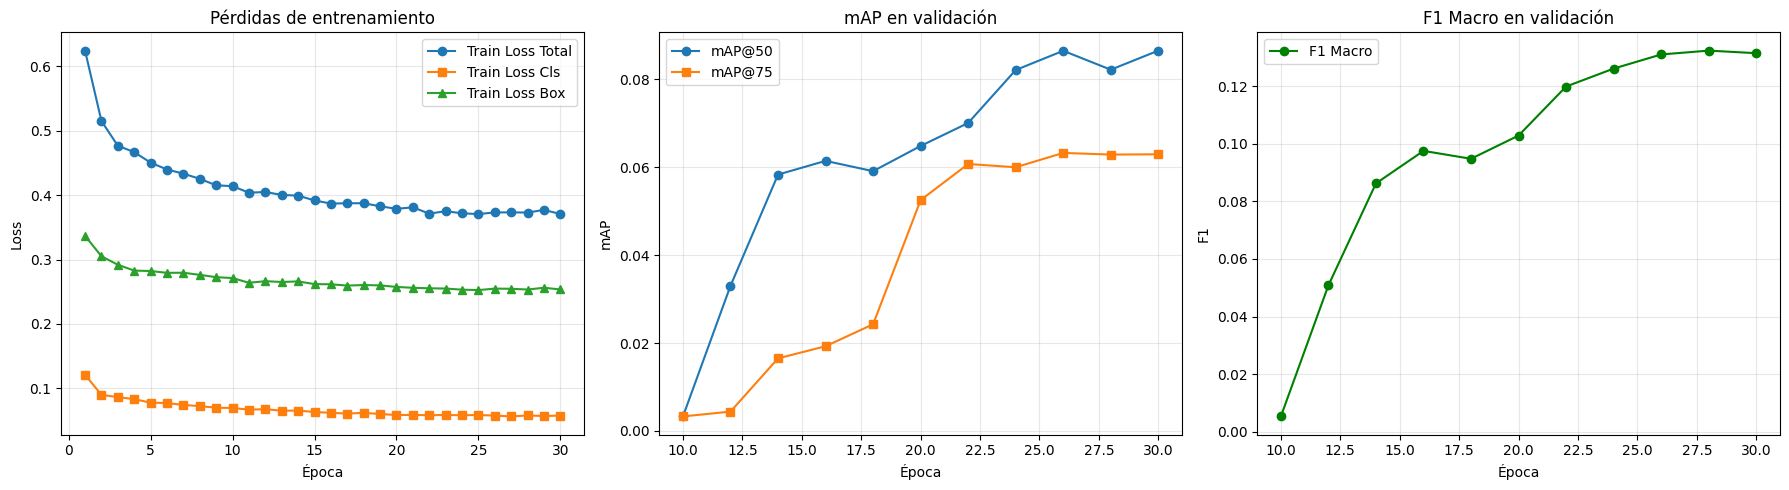

In [23]:
import pandas as pd

df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(df["epoch"], df["train_loss_total"], label="Train Loss Total", marker="o")
axes[0].plot(df["epoch"], df["train_loss_cls"], label="Train Loss Cls", marker="s")
axes[0].plot(df["epoch"], df["train_loss_box"], label="Train Loss Box", marker="^")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Pérdidas de entrenamiento")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mAP
val_epochs = df[df["val_map50"] > 0]["epoch"]
axes[1].plot(val_epochs, df[df["val_map50"] > 0]["val_map50"], label="mAP@50", marker="o")
axes[1].plot(val_epochs, df[df["val_map50"] > 0]["val_map75"], label="mAP@75", marker="s")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("mAP")
axes[1].set_title("mAP en validación")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1
axes[2].plot(val_epochs, df[df["val_map50"] > 0]["val_macro_f1"], label="F1 Macro", marker="o", color="green")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("F1")
axes[2].set_title("F1 Macro en validación")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Evaluación final en Test

In [24]:
# Cargar mejor modelo
best_ckpt = torch.load(ckpt_dir / "best_model.pth", map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"[INFO] Modelo de época {best_ckpt['epoch']} cargado (mAP@50 val: {best_ckpt['best_map50']:.4f})")


[INFO] Modelo de época 30 cargado (mAP@50 val: 0.0865)


In [25]:
test_metrics = evaluate(model, test_loader, "test", categories, score_threshold=CONFIG["score_threshold"])
print(f"\n[INFO] Mejor mAP@50 (val): {best_map50:.4f}")
print(f"[INFO] mAP@50 (test):      {test_metrics['map50']:.4f}")
print(f"[INFO] F1 macro (test):    {test_metrics['macro_f1']:.4f}")


Evaluando [TEST]: 100%|██████████| 51/51 [00:09<00:00,  5.31it/s]



───────────────────────────────────────────────────────
  [TEST] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.0710
  mAP@75      : 0.0371
  mAP@50:95   : 0.0540
  F1 macro    : 0.1107

  F1 por clase (score_threshold=0.5):
    Ambulante             P=0.067  R=0.167  F1=0.095
    Bus                   P=0.000  R=0.000  F1=0.000
    Camion                P=1.000  R=0.200  F1=0.333
    Carro                 P=1.000  R=0.079  F1=0.147
    Combi                 P=0.000  R=0.000  F1=0.000
    Motocarga             P=0.000  R=0.000  F1=0.000
    Motocicleta           P=0.500  R=0.286  F1=0.364
    Mototaxi              P=1.000  R=0.018  F1=0.035
    Persona               P=1.000  R=0.012  F1=0.023

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Ambulante             AP=0.0842
    Bus                   AP=0.0000
    Camion                AP=0.2079
    Carro                 AP=0.0715
    Combi                 AP=0.0000


In [26]:
results = {
    "config": CONFIG, "categories": categories,
    "best_epoch": best_ckpt["epoch"], "best_map50": best_map50,
    "test_metrics": test_metrics, "history": history,
}
with open(ckpt_dir / "training_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"[INFO] Resultados guardados en: {ckpt_dir / 'training_results.json'}")


[INFO] Resultados guardados en: checkpoints/training_results.json


## 14. Visualización de predicciones en test

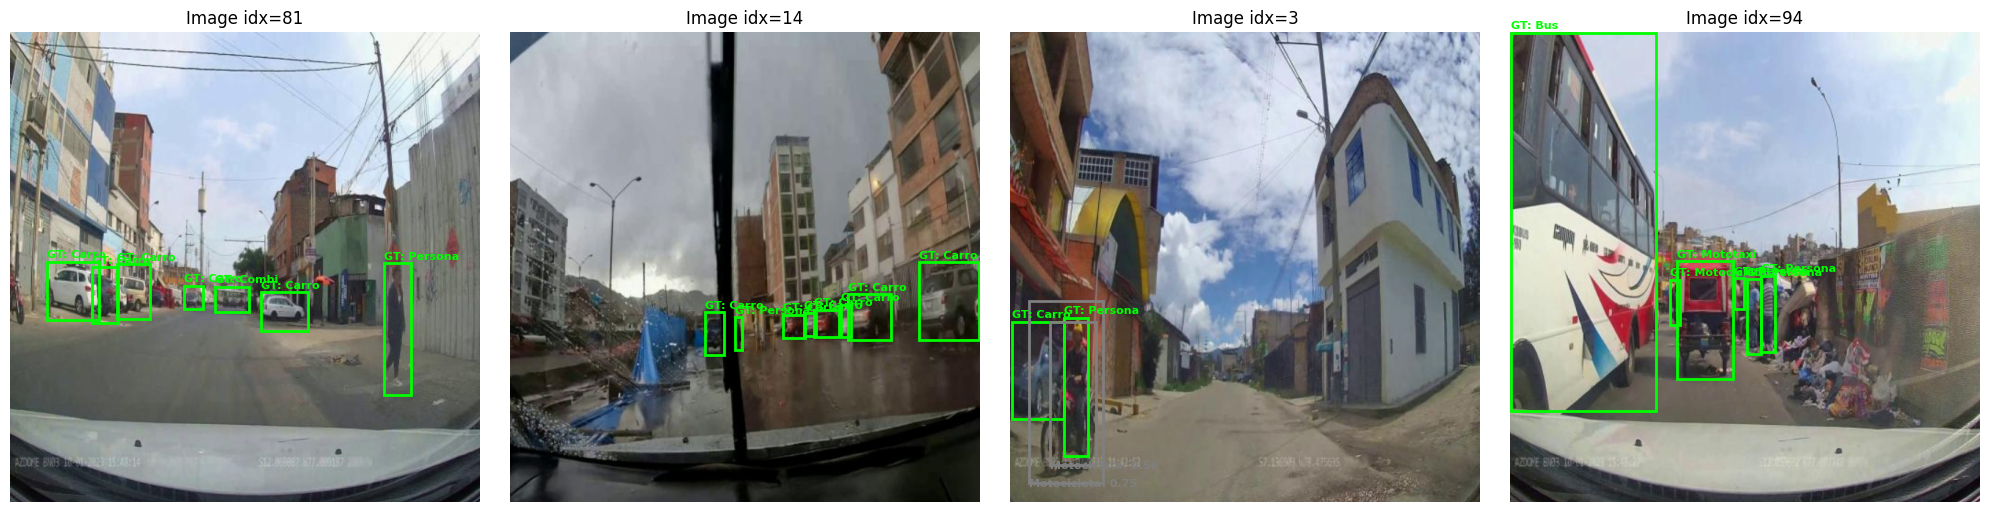

In [27]:
def visualize_predictions(model, dataset, categories, num_samples=4, score_threshold=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    if num_samples == 1:
        axes = [axes]

    class_colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

    for ax, idx in zip(axes, indices):
        image, target = dataset[idx]
        with torch.no_grad():
            pred = model([image.to(DEVICE)])[0]

        # Desnormalizar imagen para visualización
        img_np = image.cpu().numpy().transpose(1, 2, 0)
        img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np)
        ax.set_title(f"Image idx={idx}")
        ax.axis("off")

        # GT boxes (verde)
        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()
        for box, label in zip(gt_boxes, gt_labels):
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                     linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(box[0], box[1] - 5, f"GT: {categories.get(label, label)}",
                    color="lime", fontsize=8, fontweight="bold")

        # Pred boxes (rojo)
        keep = pred["scores"] >= score_threshold
        pred_boxes = pred["boxes"][keep].cpu().numpy()
        pred_labels = pred["labels"][keep].cpu().numpy()
        pred_scores = pred["scores"][keep].cpu().numpy()
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            color = class_colors[label % len(class_colors)]
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                     linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(box[0], box[3] + 5, f"{categories.get(label, label)}: {score:.2f}",
                    color=color, fontsize=8, fontweight="bold")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_ds, categories, num_samples=4)
